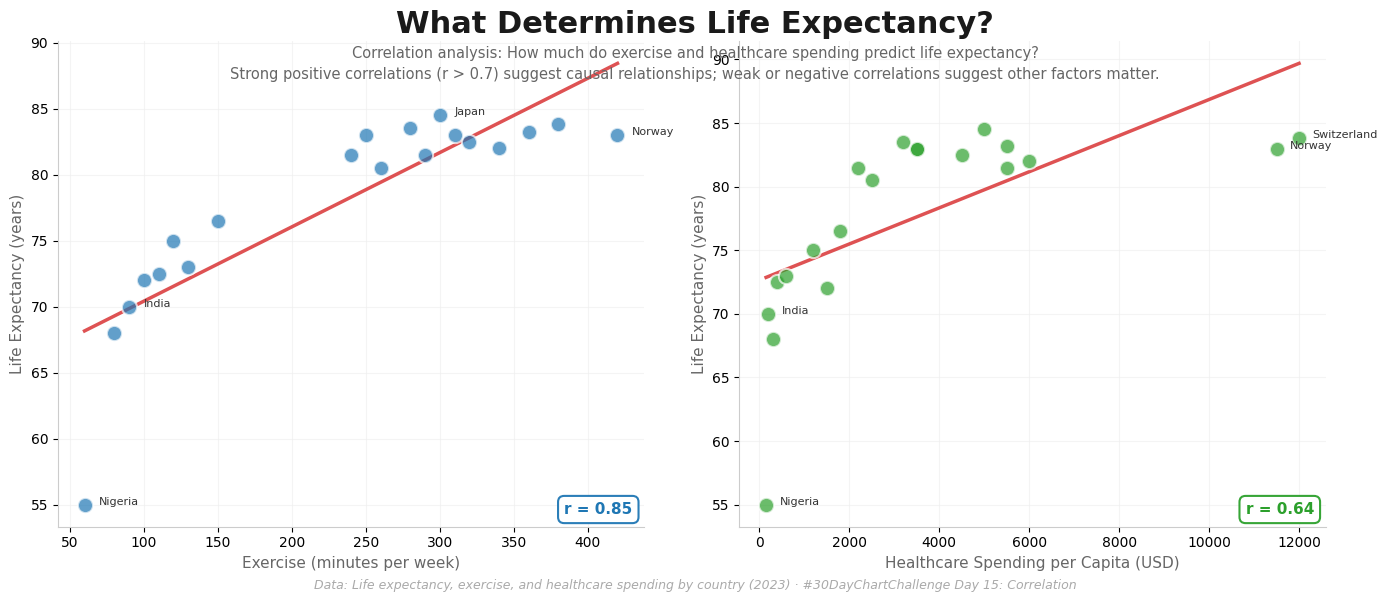

In [1]:
"""
#30DayChartChallenge — Day 15: Correlation
"Health & Lifestyle: Finding the Connections" — bivariate relationships
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Correlation between health and lifestyle factors across countries
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Health metrics by country
# ---------------------------------------------------------------------------
np.random.seed(42)

data = {
    "Country": [
        "Norway", "Japan", "Switzerland", "Australia", "Canada",
        "France", "Spain", "Italy", "Germany", "South Korea",
        "Greece", "Portugal", "Mexico", "Brazil", "India",
        "Russia", "Pakistan", "Nigeria", "Bangladesh", "Egypt"
    ],
    "Life_Expectancy": [
        83.0, 84.5, 83.8, 83.2, 82.0,
        82.5, 83.0, 83.5, 81.5, 83.0,
        80.5, 81.5, 75.0, 76.5, 70.0,
        72.0, 68.0, 55.0, 72.5, 73.0
    ],
    "Exercise_Minutes_Per_Week": [
        420, 300, 380, 360, 340,
        320, 310, 280, 290, 250,
        260, 240, 120, 150, 90,
        100, 80, 60, 110, 130
    ],
    "Healthcare_Spending_Per_Capita": [
        11500, 5000, 12000, 5500, 6000,
        4500, 3500, 3200, 5500, 3500,
        2500, 2200, 1200, 1800, 200,
        1500, 300, 150, 400, 600
    ]
}

df = pd.DataFrame(data)

# Calculate correlations
corr_life_exercise = stats.pearsonr(df["Life_Expectancy"], df["Exercise_Minutes_Per_Week"])
corr_life_spending = stats.pearsonr(df["Life_Expectancy"], df["Healthcare_Spending_Per_Capita"])

# ---------------------------------------------------------------------------
# 2. PLOT — Scatter plots with regression lines
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="#FFFFFF")

# Plot 1: Life Expectancy vs Exercise
ax1 = axes[0]
ax1.set_facecolor("#FFFFFF")

scatter1 = ax1.scatter(df["Exercise_Minutes_Per_Week"], df["Life_Expectancy"],
                       s=120, color="#1f77b4", alpha=0.7, edgecolor="white", linewidth=1.5, zorder=3)

# Regression line
z1 = np.polyfit(df["Exercise_Minutes_Per_Week"], df["Life_Expectancy"], 1)
p1 = np.poly1d(z1)
x_line = np.linspace(df["Exercise_Minutes_Per_Week"].min(), df["Exercise_Minutes_Per_Week"].max(), 100)
ax1.plot(x_line, p1(x_line), color="#d62728", linewidth=2.5, alpha=0.8, zorder=2)

# Labels for some points
for idx, row in df.iterrows():
    if row["Country"] in ["Norway", "India", "Japan", "Nigeria"]:
        ax1.text(row["Exercise_Minutes_Per_Week"] + 10, row["Life_Expectancy"],
                row["Country"], fontsize=8, color="#333333", fontweight="500")

ax1.set_xlabel("Exercise (minutes per week)", fontsize=11, color="#666666", fontweight="500")
ax1.set_ylabel("Life Expectancy (years)", fontsize=11, color="#666666", fontweight="500")
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#cccccc")
ax1.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax1.set_axisbelow(True)

# Correlation text
ax1.text(0.98, 0.02, f"r = {corr_life_exercise[0]:.2f}",
         fontsize=11, fontweight="bold", color="#1f77b4", transform=ax1.transAxes,
         ha="right", va="bottom",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor="#1f77b4", linewidth=1.5, alpha=0.95))

# Plot 2: Life Expectancy vs Healthcare Spending
ax2 = axes[1]
ax2.set_facecolor("#FFFFFF")

scatter2 = ax2.scatter(df["Healthcare_Spending_Per_Capita"], df["Life_Expectancy"],
                       s=120, color="#2ca02c", alpha=0.7, edgecolor="white", linewidth=1.5, zorder=3)

# Regression line
z2 = np.polyfit(df["Healthcare_Spending_Per_Capita"], df["Life_Expectancy"], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df["Healthcare_Spending_Per_Capita"].min(), df["Healthcare_Spending_Per_Capita"].max(), 100)
ax2.plot(x_line2, p2(x_line2), color="#d62728", linewidth=2.5, alpha=0.8, zorder=2)

# Labels for some points
for idx, row in df.iterrows():
    if row["Country"] in ["Switzerland", "Norway", "Nigeria", "India"]:
        ax2.text(row["Healthcare_Spending_Per_Capita"] + 300, row["Life_Expectancy"],
                row["Country"], fontsize=8, color="#333333", fontweight="500")

ax2.set_xlabel("Healthcare Spending per Capita (USD)", fontsize=11, color="#666666", fontweight="500")
ax2.set_ylabel("Life Expectancy (years)", fontsize=11, color="#666666", fontweight="500")
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#cccccc")
ax2.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax2.set_axisbelow(True)

# Correlation text
ax2.text(0.98, 0.02, f"r = {corr_life_spending[0]:.2f}",
         fontsize=11, fontweight="bold", color="#2ca02c", transform=ax2.transAxes,
         ha="right", va="bottom",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor="#2ca02c", linewidth=1.5, alpha=0.95))

# Overall title & subtitle
fig.text(0.5, 0.98, "What Determines Life Expectancy?",
         fontsize=22, fontweight="bold", color="#1a1a1a", ha="center", va="top")

fig.text(0.5, 0.92,
         "Correlation analysis: How much do exercise and healthcare spending predict life expectancy?\n"
         "Strong positive correlations (r > 0.7) suggest causal relationships; weak or negative correlations suggest other factors matter.",
         fontsize=10.5, color="#666666", ha="center", va="top", linespacing=1.5)

# Source
fig.text(0.5, 0.01,
         "Data: Life expectancy, exercise, and healthcare spending by country (2023) · #30DayChartChallenge Day 15: Correlation",
         fontsize=9, color="#aaaaaa", style="italic", ha="center", va="bottom")

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig("day15_correlation.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()